In [6]:
import numpy as np
import pandas as pd

# 1. Đọc bộ dữ liệu Air Quality UCI (Thay đổi đường dẫn file nếu cần)
# Giả định dữ liệu phân tách bằng dấu chấm phẩy ';' và dấu thập phân là ',' theo chuẩn gốc của UCI
df = pd.read_csv("../data/raw/AirQualityUCI.csv")

# Loại bỏ các dòng/cột trống hoàn toàn nếu có (UCI thường có một số dòng trống ở cuối file)
df = df.dropna(how="all").dropna(axis=1, how="all")

# 2. Thay thế mã lỗi -200 thành giá trị khuyết thiếu NaN
df_cleaned = df.replace(-200, np.nan)

# 3. Tính toán số lượng và tỷ lệ phần trăm dữ liệu khuyết thiếu trên từng cột
missing_count = df_cleaned.isnull().sum()
missing_ratio = (df_cleaned.isnull().sum() / len(df_cleaned)) * 100

# 4. Tổng hợp thành Bảng 3.1
# Chỉ lấy các cột cảm biến/thuộc tính liên quan (bỏ qua cột Date, Time nếu có)
sensor_cols = [col for col in df_cleaned.columns if col not in ["Date", "Time"]]

bang_3_1 = pd.DataFrame(
    {
        "Số lượng NaN": missing_count[sensor_cols],
        "Tỷ lệ khuyết thiếu (Missing ratio)": missing_ratio[sensor_cols].map(
            "{:.1f}%".format
        ),
    }
)

# Đổi tên chỉ mục hiển thị cho đẹp mắt nếu muốn
bang_3_1.index.name = "Thuộc tính / Cảm biến"

# 5. In kết quả dạng bảng Markdown để copy vào báo cáo
print(
    "Bảng 3.1. Thống kê tỷ lệ dữ liệu khuyết thiếu trên các thuộc tính sau khi xử lý mã lỗi -200 của tập UCI."
)
print(bang_3_1.to_markdown())


Bảng 3.1. Thống kê tỷ lệ dữ liệu khuyết thiếu trên các thuộc tính sau khi xử lý mã lỗi -200 của tập UCI.
| Thuộc tính / Cảm biến   |   Số lượng NaN | Tỷ lệ khuyết thiếu (Missing ratio)   |
|:------------------------|---------------:|:-------------------------------------|
| CO(GT)                  |           1683 | 18.0%                                |
| PT08.S1(CO)             |            366 | 3.9%                                 |
| NMHC(GT)                |           8443 | 90.2%                                |
| C6H6(GT)                |            366 | 3.9%                                 |
| PT08.S2(NMHC)           |            366 | 3.9%                                 |
| NOx(GT)                 |           1639 | 17.5%                                |
| PT08.S3(NOx)            |            366 | 3.9%                                 |
| NO2(GT)                 |           1642 | 17.5%                                |
| PT08.S4(NO2)            |            366 | 3.9%      

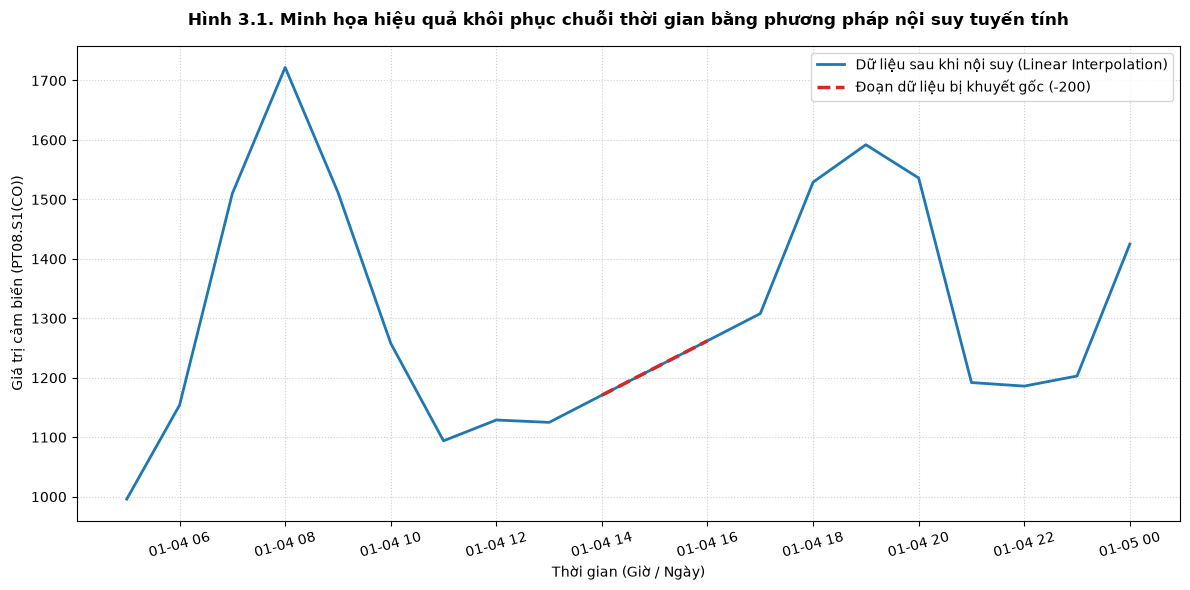

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Đọc và tiền xử lý dữ liệu đầu vào
# Giả định dữ liệu phân tách bằng dấu ';' và dấu thập phân là ','
df = pd.read_csv("../data/raw/AirQualityUCI.csv")
df = df.dropna(how="all").dropna(axis=1, how="all")

# Tạo cột Datetime hoàn chỉnh để làm trục X chuỗi thời gian
datetime_series = df['Date'] + ' ' + df['Time']
df['Datetime'] = pd.to_datetime(datetime_series, format='mixed', dayfirst=True)
    
df = df.sort_values("Datetime").reset_index(drop=True)

# 2. Xử lý giá trị lỗi -200 và áp dụng phép Nội suy Tuyến tính
target_col = "PT08.S1(CO)"

# Tạo bản sao chuỗi gốc và thay -200 thành NaN
df["Raw_Data"] = df[target_col].replace(-200, np.nan)

# Áp dụng nội suy tuyến tính cho chuỗi thời gian
df["Interpolated_Data"] = df["Raw_Data"].interpolate(method="linear")

# 3. Trích xuất một dải dữ liệu ngắn (Ví dụ: Lấy 72 hàng liên tiếp ~ 3 ngày)
# Bạn có thể đổi chỉ số từ [300:372] sang đoạn nào có chứa NaN để thấy rõ hiệu quả
sample_df = df.iloc[5:25].copy()

# 4. Vẽ biểu đồ Hình 3.1
plt.figure(figsize=(12, 6))

# Vẽ đường nét liền màu xanh: Biểu thị dữ liệu sau khi phục hồi mượt mà
plt.plot(
    sample_df["Datetime"],
    sample_df["Interpolated_Data"],
    color="#1f77b4",
    linestyle="-",
    linewidth=2,
    label="Dữ liệu sau khi nội suy (Linear Interpolation)",
)

# Vẽ đường đứt nét màu đỏ: Biểu thị đoạn dữ liệu bị khuyết gốc (-200) ban đầu
# (Chỉ vẽ ở những vị trí mà Raw_Data bị khuyết nhưng Interpolated_Data có giá trị)
plt.plot(
    sample_df["Datetime"],
    sample_df["Interpolated_Data"].where(sample_df["Raw_Data"].isna()),
    color="#d62728",
    linestyle="--",
    linewidth=2.5,
    label="Đoạn dữ liệu bị khuyết gốc (-200)",
)

# Định dạng biểu đồ
plt.title(
    "Hình 3.1. Minh họa hiệu quả khôi phục chuỗi thời gian bằng phương pháp nội suy tuyến tính",
    fontsize=12,
    pad=15,
    fontweight="bold",
)
plt.xlabel("Thời gian (Giờ / Ngày)", fontsize=10)
plt.ylabel(f"Giá trị cảm biến ({target_col})", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right", frameon=True)
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()
